In [1]:
import torch
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
tqdm.pandas()
from transformers import pipeline, AutoTokenizer,AutoModelForCausalLM
from datasets import load_dataset
from trl import PPOTrainer, PPOConfig, AutoModelForCausalLMWithValueHead
from trl.core import LengthSampler
import os
import tarfile
import pickle
import json
import matplotlib.pyplot as plt
import torch
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import wandb
import sys
sys.path.append("./docker-python/patches")
#from kaggle_secrets import UserSecretsClient
#user_secrets = UserSecretsClient()
#wandb_api = user_secrets.get_secret("wandb_api")
#wandb.login(key=wandb_api)

In [9]:
config = PPOConfig(
    model_name="lvwerra/gpt2-imdb",
    learning_rate=1.41e-5,
    #device="cuda"
    #log_with="wandb",
    #device="cuda",
    batch_size=16,
    mini_batch_size=4,
    gradient_accumulation_steps=1,
)

sent_kwargs = {"top_k": None, "function_to_apply": "none", "batch_size": 16}

In [3]:
def build_dataset(
    config,
    dataset_name="stanfordnlp/imdb",
    input_min_text_length=2,
    input_max_text_length=8,
    num_samples=5000,
):
    """
    Build dataset for training. This builds the dataset from `load_dataset`, one should
    customize this function to train the model on its own dataset.

    Args:
        dataset_name (`str`):
            The name of the dataset to be loaded.
        input_min_text_length (`int`):
            The minimum length of the input text.
        input_max_text_length (`int`):
            The maximum length of the input text.
        num_samples (`int`):
            The number of samples to be taken from the dataset.

    Returns:
        dataloader (`torch.utils.data.DataLoader`):
            The dataloader for the dataset.
    """
    tokenizer = AutoTokenizer.from_pretrained(config.model_name)
    tokenizer.pad_token = tokenizer.eos_token
    # load imdb with datasets using gpu
    ds = load_dataset(dataset_name, split="train")
    ds = ds.rename_columns({"text": "review"})
    ds = ds.filter(lambda x: len(x["review"]) > 200, batched=False)
    # take a random sample of 1000 examples
    ds = ds.shuffle(seed=42).select(range(num_samples))

    input_size = LengthSampler(input_min_text_length, input_max_text_length)

    def tokenize(sample):
        sample["input_ids"] = tokenizer.encode(sample["review"])[: input_size()]
        sample["query"] = tokenizer.decode(sample["input_ids"])
        return sample

    ds = ds.map(tokenize, batched=False)
    ds.set_format(type="torch")
    return ds

def collator(data):
    return dict((key, [d[key] for d in data]) for key in data[0])

In [4]:
dataset = build_dataset(config, input_min_text_length=4, input_max_text_length=8, num_samples=1000)

In [5]:
model = AutoModelForCausalLMWithValueHead.from_pretrained(config.model_name).to("cuda")
tokenizer = AutoTokenizer.from_pretrained(config.model_name)
tokenizer.pad_token = tokenizer.eos_token
print("Model and tokenizer loaded.")
print(f"eos_token: {tokenizer.eos_token}, pad_token: {tokenizer.pad_token}")
ref_model = AutoModelForCausalLMWithValueHead.from_pretrained(config.model_name).to("cuda")

Model and tokenizer loaded.
eos_token: <|endoftext|>, pad_token: <|endoftext|>


In [10]:
ppo_trainer = PPOTrainer(
    config, model, ref_model, tokenizer, dataset=dataset, data_collator=collator
)

device = ppo_trainer.accelerator.device
print(f"Using device: {device}")

#if ppo_trainer.accelerator.num_processes == 1:
#    device_id = 0 if torch.cuda.is_available() else "cpu"  # to avoid a `pipeline` bug
#    print(f"Using device_id: {device_id}")
sentiment_pipe = pipeline(
    "sentiment-analysis", model="lvwerra/distilbert-imdb", device=0
)

# move model, ref_model and dataset to device
#ppo_trainer.model.to("cuda")
#ppo_trainer.ref_model.to("cuda")
#ppo_trainer.dataset = ppo_trainer.dataset.map(
#    lambda x: {k: v.to(device) for k, v in x.items()}
#)


Using device: cuda


In [7]:
text = "this movie was really bad!!"
print(sentiment_pipe(text, **sent_kwargs))

text = "this movie was really good!!"
print(sentiment_pipe(text, **sent_kwargs))

[{'label': 'NEGATIVE', 'score': 2.335048198699951}, {'label': 'POSITIVE', 'score': -2.726576089859009}]
[{'label': 'POSITIVE', 'score': 2.557039737701416}, {'label': 'NEGATIVE', 'score': -2.2947897911071777}]


In [13]:
generation_kwargs = {
    "min_length": -1,
    "top_k": 0.0,
    "top_p": 1.0,
    "do_sample": True,
    "pad_token_id": tokenizer.eos_token_id,
}

output_min_length = 32
output_max_length = 64
output_length_sampler = LengthSampler(output_min_length, output_max_length)


In [12]:
class CFG:
    is_training = True

In [14]:
if CFG.is_training:
    for epoch, batch in enumerate(tqdm(ppo_trainer.dataloader)):
        #query_tensors = batch["input_ids"]
        query_tensors = [t.to("cuda") for t in batch["input_ids"]]
        print(f"Batch size: {len(query_tensors)}")

        #### Get response from gpt2
        response_tensors = []
        for query in query_tensors:
            #print(f"len query - {len(query)}")
            gen_len = output_length_sampler()
            #print(f"gen_len - {gen_len}")
            generation_kwargs["max_new_tokens"] = gen_len
            query_response = ppo_trainer.generate(query, **generation_kwargs).squeeze()
            #print(query_response.shape)
            response_len = len(query_response) - len(query)
            #print(f"response_len - {response_len}")
            response_tensors.append(query_response[-response_len:])
        batch["response"] = [tokenizer.decode(r.squeeze()) for r in response_tensors]

        #### Compute sentiment score
        texts = [q + r for q, r in zip(batch["query"], batch["response"])]
        print(f"number of texts for sentiment analysis: {len(texts)}")
        pipe_outputs = sentiment_pipe(texts, **sent_kwargs)
        positive_scores = [
            item["score"]
            for output in pipe_outputs
            for item in output
            if item["label"] == "POSITIVE"
        ]
        print(f"number of positive scores: {len(positive_scores)}")
        #rewards = [torch.tensor(score) for score in positive_scores]
        rewards = [torch.tensor(score, device="cuda") for score in positive_scores]
        print(f"number of rewards: {len(rewards)}")

        #### Run PPO step
        stats = ppo_trainer.step(query_tensors, response_tensors, rewards)
        ppo_trainer.log_stats(stats, batch, rewards)

  0%|          | 0/62 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Batch size: 16
number of texts for sentiment analysis: 16
number of positive scores: 16
number of rewards: 16


  2%|▏         | 1/62 [00:22<22:31, 22.16s/it]

Batch size: 16
number of texts for sentiment analysis: 16
number of positive scores: 16
number of rewards: 16


  3%|▎         | 2/62 [01:12<38:55, 38.92s/it]

...

 97%|█████████▋| 60/62 [28:53<00:50, 25.40s/it]

Batch size: 16
number of texts for sentiment analysis: 16
number of positive scores: 16
number of rewards: 16


 98%|█████████▊| 61/62 [29:19<00:25, 25.51s/it]

Batch size: 16
number of texts for sentiment analysis: 16
number of positive scores: 16
number of rewards: 16


100%|██████████| 62/62 [29:44<00:00, 28.79s/it]


In [15]:
if CFG.is_training:
    model.save_pretrained("gpt2-imdb-pos-v2")
    tokenizer.save_pretrained("gpt2-imdb-pos-v2")

In [16]:
bs = 16
game_data = dict()
dataset.set_format("pandas")
df_batch = dataset[:].sample(bs)
print(f"df_batch shape - {df_batch.shape}")
game_data["query"] = df_batch["query"].tolist()
query_tensors = df_batch["input_ids"].tolist()

df_batch shape - (16, 4)


In [17]:
df_batch

,review,label,input_ids,query
647,<br /><br />I take issue with the other review...,1,"[27, 1671, 1220, 6927]",<br /><
998,While the idea is more original than most Sci-...,0,"[3633, 262, 2126, 318, 517, 2656, 621]",While the idea is more original than
951,"The '60s is an occasionally entertaining film,...",0,"[464, 705, 1899, 82, 318, 281]",The '60s is an
4,"The late, great Robert Bloch (author of PSYCHO...",1,"[464, 2739, 11, 1049]","The late, great"
873,"With this movie, it's all about style, atmosph...",1,"[3152, 428, 3807, 11, 340, 338, 477]","With this movie, it's all"
677,There is a scene in this film at about the 42 ...,0,"[1858, 318, 257, 3715, 287, 428]",There is a scene in this
232,A truly dreadful film. I did not know initiall...,0,"[32, 4988, 35483, 2646, 13]",A truly dreadful film.
304,I went to this movie expecting a concise movie...,0,"[40, 1816, 284, 428, 3807]",I went to this movie
601,I can catogoricaly and unequivocally say that ...,0,"[40, 460, 3797, 519, 12409]",I can catogorical
27,Inappropriate. The PG rating that this movie g...,0,"[818, 13335, 13, 383, 23842, 7955, 326]",Inappropriate. The PG rating that


In [19]:
print(len(query_tensors))
query_tensors[0]

16


array([  27, 1671, 1220, 6927])

In [21]:
response_tensors_ref, response_tensors = [], []

gen_kwargs = {
    "min_length": -1,
    "top_k": 0.0,
    "top_p": 1.0,
    "do_sample": True,
    "pad_token_id": tokenizer.eos_token_id,
}

#### get response from gpt2 and gpt2_ref
for i in range(bs):
    query = torch.tensor(query_tensors[i]).to(device)

    gen_len = output_length_sampler()
    query_response = ref_model.generate(
        query.unsqueeze(0), max_new_tokens=gen_len, **gen_kwargs
    ).squeeze()
    response_len = len(query_response) - len(query)
    response_tensors_ref.append(query_response[-response_len:])

    query_response = model.generate(
        query.unsqueeze(0), max_new_tokens=gen_len, **gen_kwargs
    ).squeeze()
    response_len = len(query_response) - len(query)
    response_tensors.append(query_response[-response_len:])

In [22]:
#### decode responses
game_data["response (before)"] = [
    tokenizer.decode(response_tensors_ref[i]) for i in range(bs)
]
game_data["response (after)"] = [
    tokenizer.decode(response_tensors[i]) for i in range(bs)
]

In [23]:
#### sentiment analysis of query/response pairs before/after
texts = [q + r for q, r in zip(game_data["query"], game_data["response (before)"])]
pipe_outputs = sentiment_pipe(texts, **sent_kwargs)
positive_scores = [
    item["score"]
    for output in pipe_outputs
    for item in output
    if item["label"] == "POSITIVE"
]
game_data["rewards (before)"] = positive_scores

texts = [q + r for q, r in zip(game_data["query"], game_data["response (after)"])]
pipe_outputs = sentiment_pipe(texts, **sent_kwargs)
positive_scores = [
    item["score"]
    for output in pipe_outputs
    for item in output
    if item["label"] == "POSITIVE"
]
game_data["rewards (after)"] = positive_scores

In [24]:
# store results in a dataframe
df_results = pd.DataFrame(game_data)
df_results

,query,response (before),response (after),rewards (before),rewards (after)
0,<br /><,br />He begins letting me watch all the animat...,"br />A beautiful, intricate, dramatic, and som...",2.046387,2.640064
1,While the idea is more original than,"cohesive, it's an entirely different case.<br...","superb, a great film to experience.<|endoftext|>",1.193703,2.664881
2,The '60s is an,interesting subject. I've seen high-tech tech...,excellent movie.<|endoftext|>,0.837941,2.618419
3,"The late, great","James Earl Jones has done more 51s, which wer...",movie.<|endoftext|>,1.846741,1.494183
4,"With this movie, it's all",over the place.<br /><br />While it is an old...,good fun.<|endoftext|>,-2.271682,2.551187
5,There is a scene in this,film that gives an idea of the harrowing viol...,film that can grately capture the genius of t...,0.251798,2.829935
6,A truly dreadful film.,<|endoftext|>,not worth the movie but certainly recommend f...,-2.853628,-2.868845
7,I went to this movie,expecting to be one of Saudi Arabia's best co...,for a great cinematic experience.<|endoftext|>,-2.653075,2.043346
8,I can catogorical,to translate timeiana is a very common genre ...,"about it - it is a great drama, a wonderful f...",1.705058,2.820325
9,Inappropriate. The PG rating that,was provided for this film is inaccurate I ta...,"had seemed to dominate that movie, but I like...",-2.028571,2.419471


In [25]:
def calculate_mean_rewards(df):
    """Calculate the mean rewards before and after."""
    mean_reward_before = df["rewards (before)"].mean()
    mean_reward_after = df["rewards (after)"].mean()
    mean_reward_gain = mean_reward_after - mean_reward_before
    return mean_reward_before, mean_reward_after, mean_reward_gain

def display_mean_rewards(mean_before, mean_after, gain):
    """Display the calculated mean rewards."""
    display(Markdown((f"## Average Reward Improvement: \n\nThe model’s policy resulted in a mean reward increase of {gain:.4f}, indicating the net performance gain after optimization. Initial average reward: {mean_before:.4f}. Post-optimization average reward: {mean_after:.4f}.")))

def plot_mean_rewards(mean_before, mean_after, gain):
    """Plot a bar chart for the mean rewards before, after, and the gain."""
    labels = ['Mean Reward (Before)', 'Mean Reward (After)', 'Mean Reward Gain']
    values = [mean_before, mean_after, gain]
    
    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=['blue', 'green', 'orange'])
    plt.title('Mean Reward Comparison')
    plt.ylabel('Reward Value')
    plt.ylim(min(values) - abs(min(values) * 0.1), max(values) + abs(max(values) * 0.1))  # Add some margin
    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f"{v:.4f}", ha='center', va='bottom')  # Display the values on top of bars
    plt.show()


## Average Reward Improvement: 

The model’s policy resulted in a mean reward increase of 2.0554, indicating the net performance gain after optimization. Initial average reward: -0.2308. Post-optimization average reward: 1.8246.

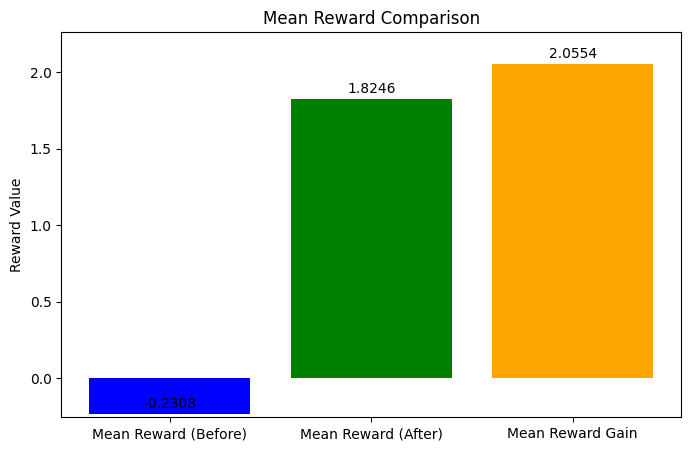

In [26]:
# Main execution
mean_reward_before, mean_reward_after, mean_reward_gain = calculate_mean_rewards(df_results)
display_mean_rewards(mean_reward_before, mean_reward_after, mean_reward_gain)
plot_mean_rewards(mean_reward_before, mean_reward_after, mean_reward_gain)